# Cognitive ASR Thesis Results Analysis

Catastrophic forgetting during LLM instruction fine-tuning.  
Core finding: forgetting is selective along a **cognitive axis** — multi-step derivation tasks degrade, pattern recognition tasks improve.  
Mitigation: **Adaptive Self-Rehearsal (ASR v2)** with cognitive-tier probes and a self-generated rehearsal bank.

## 1. Setup

In [ ]:
import os, json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# Derive ROOT from the notebook's own location so moving the project doesn't break paths.
# VS Code sets __vsc_ipynb_file__; other Jupyter environments fall back to CWD.
try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
except NameError:
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

FIG_DIR = os.path.join(ROOT, "cognitive_asr", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

METRIC_KEYS = {
    "gsm8k":         "exact_match,flexible-extract",
    "triviaqa":       "exact_match,remove_whitespace",
    "arc_challenge":  "acc_norm,none",
    "arc_easy":       "acc_norm,none",
    "hellaswag":      "acc_norm,none",
    "boolq":          "acc,none",
    "winogrande":     "acc,none",
    "piqa":           "acc_norm,none",
    "openbookqa":     "acc_norm,none",
    "copa":           "acc,none",
    "rte":            "acc,none",
    "lambada_openai": "acc,none",
    "mmlu":           "acc,none",
}
_DEFAULT = ["acc_norm,none", "acc,none"]

def _score(task, mets):
    k = METRIC_KEYS.get(task)
    if k and k in mets:
        return round(mets[k] * 100, 2)
    for k in _DEFAULT:
        if k in mets:
            return round(mets[k] * 100, 2)
    return None

def load_run(run_dir):
    scores = {}
    for root, _, files in os.walk(run_dir):
        for fname in files:
            if not (fname.startswith("results_") and fname.endswith(".json")):
                continue
            with open(os.path.join(root, fname)) as f:
                d = json.load(f)
            for task, mets in d.get("results", {}).items():
                v = _score(task, mets)
                if v is not None:
                    scores[task] = v
    return scores

base      = load_run(os.path.join(ROOT, "results", "base", "Qwen__Qwen2.5-3B"))
asr_s42   = load_run(os.path.join(ROOT, "cognitive_asr", "results", "results", "seed42"))
asr_s1337 = load_run(os.path.join(ROOT, "cognitive_asr", "results", "results", "seed1337"))
asr_div30 = load_run(os.path.join(ROOT, "cognitive_asr", "results", "results", "seed42_div30"))

print(f"ROOT: {ROOT}")
print(f"base={len(base)}, s42={len(asr_s42)}, s1337={len(asr_s1337)}, div30={len(asr_div30)}")
print(f"GSM8K  base={base.get('gsm8k')}  (flexible-extract)")
print(f"TrivQA base={base.get('triviaqa')} (remove_whitespace)")


In [5]:
vanilla = {
    "gsm8k": 55.69, "triviaqa": 23.10, "mmlu": 62.95, "arc_easy": 77.95,
    "arc_challenge": 51.15, "boolq": 82.75, "copa": 88.00, "winogrande": 69.85,
    "hellaswag": 72.48, "lambada_openai": 62.90, "piqa": 78.40,
    "openbookqa": 43.10, "rte": 70.40,
    "mmlu_abstract_algebra": 41.00, "mmlu_formal_logic": 41.27,
    "mmlu_college_chemistry": 44.00, "mmlu_college_physics": 47.06,
    "mmlu_electrical_engineering": 60.00, "mmlu_high_school_physics": 39.74,
    "mmlu_medical_genetics": 76.00, "mmlu_human_sexuality": 77.86,
    "mmlu_management": 82.52, "mmlu_econometrics": 50.00,
}


In [6]:
def load_traj(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

TRAJ_DIR = os.path.join(ROOT, "cognitive_asr", "probe_trajectories")
trajs = {}
for name, fname in [("seed42", "seed42.jsonl"), ("seed1337", "seed1337.jsonl"),
                    ("div30", "div30_seed42.jsonl")]:
    p = os.path.join(TRAJ_DIR, fname)
    if os.path.exists(p):
        trajs[name] = load_traj(p)
        r0 = trajs[name][0]
        print(f"{name}: {len(trajs[name])} records | "
              f"accs={list(r0['accs'].keys())} | intervention_active={r0['intervention_active']}")
    else:
        print(f"{name}: NOT FOUND ({fname})")


seed42: NOT FOUND (seed42.jsonl)
seed1337: NOT FOUND (seed1337.jsonl)
div30: NOT FOUND (div30_seed42.jsonl)


In [4]:
TASKS_13 = [
    "gsm8k", "triviaqa", "mmlu", "arc_challenge", "arc_easy", "hellaswag",
    "piqa", "openbookqa", "boolq", "copa", "winogrande", "lambada_openai", "rte",
]
DERIVATION = [
    "mmlu_abstract_algebra", "mmlu_formal_logic", "mmlu_college_chemistry",
    "mmlu_college_physics", "mmlu_electrical_engineering", "mmlu_high_school_physics",
]
PATTERN = [
    "mmlu_medical_genetics", "mmlu_human_sexuality",
    "mmlu_management", "mmlu_econometrics",
]

COL_VAN, COL_ASR, COL_DIV = "#d62728", "#2ca02c", "#1f77b4"

def avg_seeds(task):
    a, b = asr_s42.get(task), asr_s1337.get(task)
    if a is not None and b is not None:
        return round((a + b) / 2, 2)
    return a if a is not None else b

def vand(task):
    b, v = base.get(task), vanilla.get(task)
    return round(v - b, 2) if b is not None and v is not None else None

def asrd(task):
    b, a = base.get(task), avg_seeds(task)
    return round(a - b, 2) if b is not None and a is not None else None

def divd(task):
    b, d = base.get(task), asr_div30.get(task)
    return round(d - b, 2) if b is not None and d is not None else None

def disp(t):
    return (t.replace("mmlu_", "")
             .replace("lambada_openai", "LAMBADA")
             .replace("_", " ").title())

def save_fig(name):
    for ext in ["png", "pdf"]:
        kw = {"bbox_inches": "tight"}
        if ext == "png":
            kw["dpi"] = 300
        plt.savefig(os.path.join(FIG_DIR, f"{name}.{ext}"), **kw)
    plt.show()
    print(f"Saved: {name}")

print("Helpers ready.")


Helpers ready.


## 2. Tables

In [5]:
def fmt(x, delta=False):
    if x is None:
        return "—"
    return f"{x:+.2f}" if delta else f"{x:.2f}"

W = [20, 7, 8, 9, 9, 9, 8, 7, 7, 7]
HDR = ["Task", "Base", "Vanilla", "ASR-s42", "ASR-s1337", "ASR-Avg", "Div30",
       "Van_Δ", "ASR_Δ", "Div_Δ"]

print("13-TASK COMPARISON (all values %, Δ in pp)")
sep = "  ".join(h.ljust(w) if i == 0 else h.rjust(w) for i, (h, w) in enumerate(zip(HDR, W)))
print(sep)
print("-" * len(sep))
for t in TASKS_13:
    b, v  = base.get(t), vanilla.get(t)
    s42, s13 = asr_s42.get(t), asr_s1337.get(t)
    avg, d30 = avg_seeds(t), asr_div30.get(t)
    vals = [t, fmt(b), fmt(v), fmt(s42), fmt(s13), fmt(avg), fmt(d30),
            fmt(vand(t), True), fmt(asrd(t), True), fmt(divd(t), True)]
    row = "  ".join(val.ljust(w) if i == 0 else val.rjust(w)
                    for i, (val, w) in enumerate(zip(vals, W)))
    marker = " <<<" if vand(t) is not None and vand(t) < -5 else ""
    print(row + marker)
print()
print("<<< = vanilla drops >5 pp")


13-TASK COMPARISON (all values %, Δ in pp)
Task                     Base   Vanilla    ASR-s42  ASR-s1337    ASR-Avg     Div30    Van_Δ    ASR_Δ    Div_Δ
-------------------------------------------------------------------------------------------------------------
gsm8k                       —     55.69          —          —          —         —        —        —        —
triviaqa                    —     23.10          —          —          —         —        —        —        —
mmlu                        —     62.95          —          —          —         —        —        —        —
arc_challenge               —     51.15          —          —          —         —        —        —        —
arc_easy                    —     77.95          —          —          —         —        —        —        —
hellaswag                   —     72.48          —          —          —         —        —        —        —
piqa                        —     78.40          —          —          —     

In [6]:
print("MMLU COGNITIVE AXIS SUBJECTS")
for group, subjects in [("Derivation", DERIVATION), ("Pattern Recognition", PATTERN)]:
    print(f"\n--- {group} ---")
    print(f"{'Subject':<28} {'Base':>7} {'Vanilla':>8} {'ASR-Avg':>9} "
          f"{'Div30':>7} {'Van_Δ':>7} {'ASR_Δ':>7} {'Div_Δ':>7}")
    print("-" * 85)
    for t in subjects:
        b, v = base.get(t), vanilla.get(t)
        avg, d30 = avg_seeds(t), asr_div30.get(t)
        print(f"{disp(t):<28} {fmt(b):>7} {fmt(v):>8} {fmt(avg):>9} "
              f"{fmt(d30):>7} {fmt(vand(t),True):>7} {fmt(asrd(t),True):>7} {fmt(divd(t),True):>7}")


MMLU COGNITIVE AXIS SUBJECTS

--- Derivation ---
Subject                         Base  Vanilla   ASR-Avg   Div30   Van_Δ   ASR_Δ   Div_Δ
-------------------------------------------------------------------------------------
Abstract Algebra                   —    41.00         —       —       —       —       —
Formal Logic                       —    41.27         —       —       —       —       —
College Chemistry                  —    44.00         —       —       —       —       —
College Physics                    —    47.06         —       —       —       —       —
Electrical Engineering             —    60.00         —       —       —       —       —
High School Physics                —    39.74         —       —       —       —       —

--- Pattern Recognition ---
Subject                         Base  Vanilla   ASR-Avg   Div30   Van_Δ   ASR_Δ   Div_Δ
-------------------------------------------------------------------------------------
Medical Genetics                   —    76.00 

## 3. fig_13task_delta — 13-Task Horizontal Delta Bar Chart

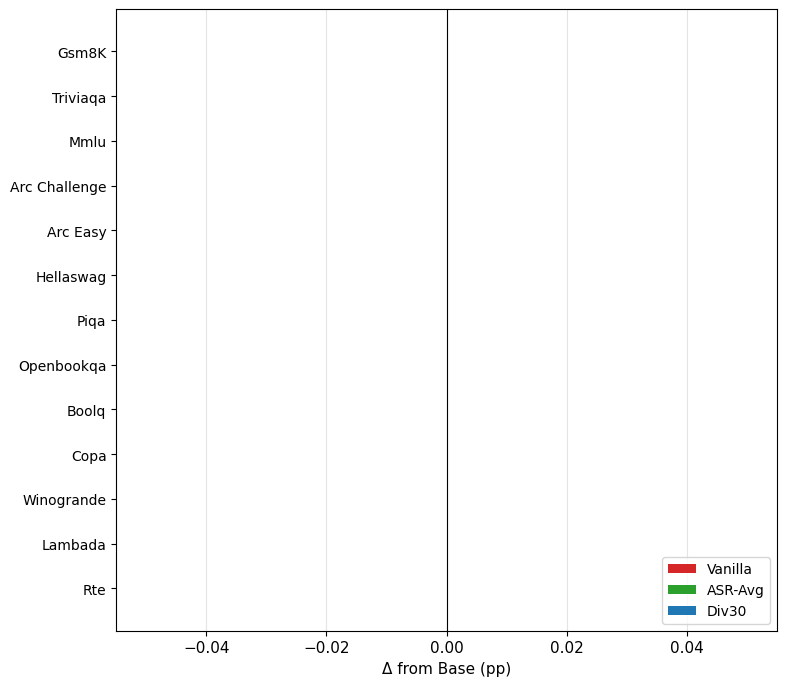

Saved: fig_13task_delta


In [7]:
tasks_sorted = sorted(TASKS_13, key=lambda t: vand(t) if vand(t) is not None else 0)
n     = len(tasks_sorted)
bar_h = 0.22
y     = np.arange(n)

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_axisbelow(True)
ax.grid(axis="x", color="lightgray", alpha=0.6, lw=0.8)

for off, label, color, fn in [
    (-bar_h, "Vanilla",  COL_VAN, vand),
    (0,      "ASR-Avg",  COL_ASR, asrd),
    (+bar_h, "Div30",    COL_DIV, divd),
]:
    vals = [fn(t) or 0 for t in tasks_sorted]
    ax.barh(y + off, vals, bar_h * 0.88, label=label, color=color)

ax.set_yticks(y)
ax.set_yticklabels([disp(t) for t in tasks_sorted], fontsize=10)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Δ from Base (pp)")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
save_fig("fig_13task_delta")


## 4. fig_cognitive_subjects & fig_pattern_subjects

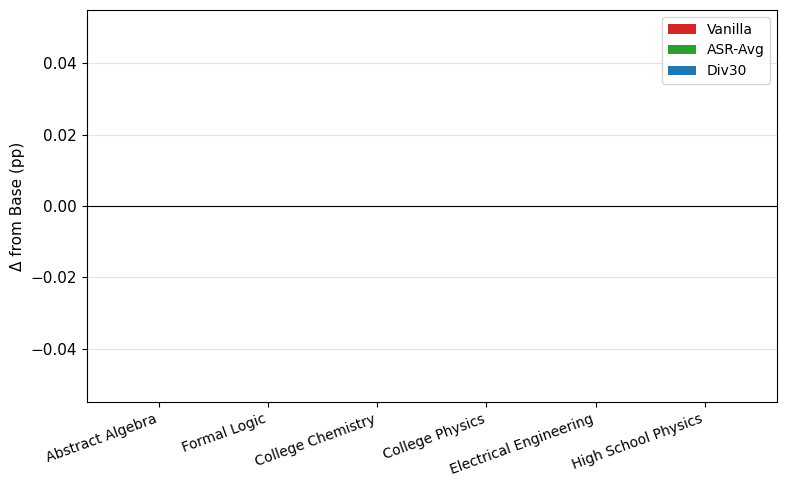

Saved: fig_cognitive_subjects


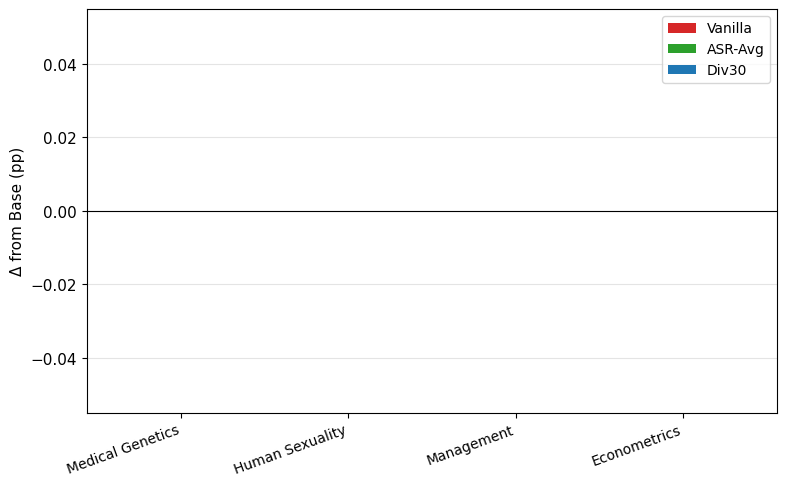

Saved: fig_pattern_subjects


In [8]:
def plot_mmlu_group(subjects, fname):
    data   = [(t, vand(t) or 0, asrd(t) or 0, divd(t) or 0) for t in subjects]
    labels = [disp(t) for t, *_ in data]
    x, w   = np.arange(len(subjects)), 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="lightgray", alpha=0.6, lw=0.8)
    ax.bar(x - w, [r[1] for r in data], w, label="Vanilla",  color=COL_VAN)
    ax.bar(x,     [r[2] for r in data], w, label="ASR-Avg", color=COL_ASR)
    ax.bar(x + w, [r[3] for r in data], w, label="Div30",   color=COL_DIV)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("Δ from Base (pp)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    save_fig(fname)

plot_mmlu_group(DERIVATION, "fig_cognitive_subjects")
plot_mmlu_group(PATTERN,    "fig_pattern_subjects")


## 5. fig_probe_trajectory — Tier Accuracy Over Training Steps

In [9]:
TIER_COLORS = {"1": COL_VAN, "2": COL_DIV, "3": COL_ASR}
TIER_LABELS = {"1": "Tier 1 (Derivation)", "2": "Tier 2 (Language)", "3": "Tier 3 (Pattern)"}
TRAJ_ORDER  = [("seed42", "seed42"), ("seed1337", "seed1337"), ("div30", "div30")]

available = [(label, trajs[key]) for label, key in TRAJ_ORDER if key in trajs]
n_plots   = len(available)

if n_plots == 0:
    print("No trajectory files found.")
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(4.5 * n_plots + 0.5, 5), sharey=True)
    if n_plots == 1:
        axes = [axes]

    for ax, (run_name, data) in zip(axes, available):
        steps = [r["step"] for r in data]

        # shade intervention-active spans red
        in_span = span_start = None
        for r in data:
            active = r.get("intervention_active", False)
            if active and not in_span:
                span_start, in_span = r["step"], True
            elif not active and in_span:
                ax.axvspan(span_start, r["step"], color="red", alpha=0.09, zorder=0)
                in_span = None
        if in_span and span_start is not None:
            ax.axvspan(span_start, steps[-1], color="red", alpha=0.09, zorder=0)

        for tier in sorted(data[0]["accs"].keys()):
            ys = [r["accs"][tier] * 100 for r in data]
            ax.plot(steps, ys, label=TIER_LABELS.get(tier, f"Tier {tier}"),
                    color=TIER_COLORS.get(tier, "gray"), linewidth=1.8)

        ax.set_xlabel("Training Step")
        if ax is axes[0]:
            ax.set_ylabel("Probe Accuracy (%)")
        ax.set_title(run_name, fontweight="bold")
        ax.legend(fontsize=9)
        ax.set_ylim(0, 105)
        ax.grid(axis="y", color="lightgray", alpha=0.6, lw=0.8)

    if n_plots < 3:
        print(f"Note: {n_plots}/3 trajectory files found (div30_seed42.jsonl missing).")
    plt.tight_layout()
    save_fig("fig_probe_trajectory")


No trajectory files found.


## 6. fig_rehearsal_composition — Rehearsal Bank Pie Charts

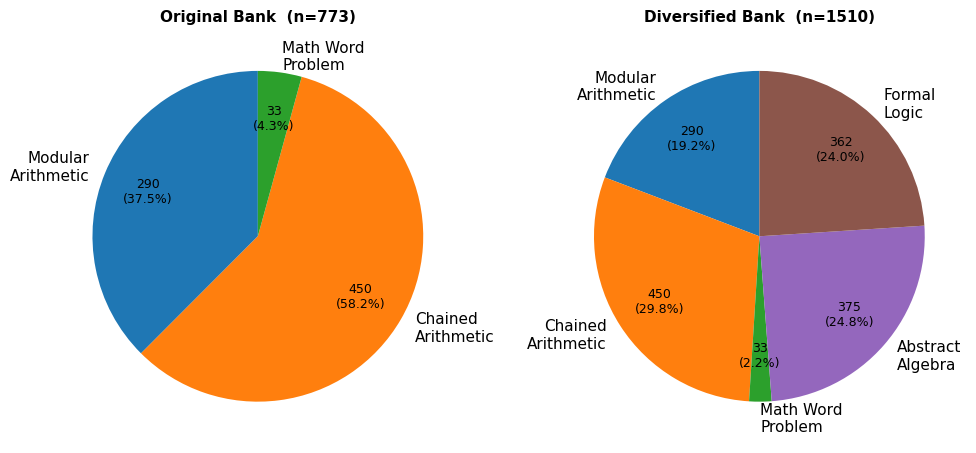

Saved: fig_rehearsal_composition


In [10]:
orig_bank = {
    "Modular\nArithmetic": 290,
    "Chained\nArithmetic": 450,
    "Math Word\nProblem":  33,
}
div30_bank = {
    "Modular\nArithmetic": 290,
    "Chained\nArithmetic": 450,
    "Math Word\nProblem":  33,
    "Abstract\nAlgebra":   375,
    "Formal\nLogic":       362,
}

PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for ax, bank, title in [(ax1, orig_bank, "Original Bank"),
                        (ax2, div30_bank, "Diversified Bank")]:
    vals   = list(bank.values())
    labels = list(bank.keys())
    total  = sum(vals)
    autopct_fn = lambda pct, t=total: f"{int(round(pct/100*t))}\n({pct:.1f}%)"
    wedges, texts, auts = ax.pie(
        vals, labels=labels, colors=PALETTE[:len(bank)],
        autopct=autopct_fn, startangle=90, pctdistance=0.72,
    )
    for at in auts:
        at.set_fontsize(9)
    ax.set_title(f"{title}  (n={total})", fontsize=11, fontweight="bold")

plt.tight_layout()
save_fig("fig_rehearsal_composition")


## Summary

In [11]:
saved = sorted(os.listdir(FIG_DIR))
print(f"Figures in {FIG_DIR}:")
for fn in saved:
    size = os.path.getsize(os.path.join(FIG_DIR, fn))
    print(f"  {fn:<52} {size//1024:>5} KB")


Figures in /home/vivaswan/self_instruct/final_backup/cognitive_asr/figures:
  fig_13task_delta.pdf                                    19 KB
  fig_13task_delta.png                                   112 KB
  fig_cognitive_subjects.pdf                              15 KB
  fig_cognitive_subjects.png                             159 KB
  fig_pattern_subjects.pdf                                15 KB
  fig_pattern_subjects.png                               123 KB
  fig_rehearsal_composition.pdf                           24 KB
  fig_rehearsal_composition.png                          224 KB
